In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv("cipla_stock_data.csv")

df.head()

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,06-Mar-2026,EQ,"1,326.10","1,332.70","1,315.00","1,326.40","1,323.80","1,321.20","1,323.74","1,673.00","1,281.70",695774,"92,10,25,773.30",31127
1,05-Mar-2026,EQ,"1,314.90","1,332.10","1,314.90","1,313.20","1,327.50","1,326.40","1,323.05","1,673.00","1,281.70",1184085,"1,56,66,07,176.50",58140
2,04-Mar-2026,EQ,"1,348.20","1,348.90","1,311.00","1,351.60","1,313.00","1,313.20","1,324.42","1,673.00","1,281.70",1938762,"2,56,77,33,353.20",94697
3,02-Mar-2026,EQ,"1,313.00","1,354.50","1,313.00","1,348.20","1,351.00","1,351.60","1,341.45","1,673.00","1,281.70",1899674,"2,54,83,24,241.50",69800
4,27-Feb-2026,EQ,"1,353.00","1,356.90","1,338.50","1,358.10","1,346.00","1,348.20","1,346.64","1,673.00","1,281.70",2609711,"3,51,43,52,815.60",58836


In [31]:
df = df[['DATE', 'CLOSE']]

df.head()

,DATE,CLOSE
0,06-Mar-2026,"1,321.20"
1,05-Mar-2026,"1,326.40"
2,04-Mar-2026,"1,313.20"
3,02-Mar-2026,"1,351.60"
4,27-Feb-2026,"1,348.20"


In [32]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y') # Convert 'DATE' column to datetime objects
df = df.set_index('DATE') # Set the 'DATE' column as the DataFrame index
df = df.sort_index(ascending=True) # Sort the DataFrame by date in ascending order
print("DataFrame index set to DATE and sorted:")
print(df.head())
print(df.tail())

DataFrame index set to DATE and sorted:
               CLOSE
DATE                
2025-03-10  1,462.75
2025-03-11  1,445.75
2025-03-12  1,454.30
2025-03-13  1,461.90
2025-03-17  1,492.60
               CLOSE
DATE                
2026-02-27  1,348.20
2026-03-02  1,351.60
2026-03-04  1,313.20
2026-03-05  1,326.40
2026-03-06  1,321.20


In [33]:
print(df.isnull().sum())

CLOSE    0
dtype: int64


In [34]:
df['CLOSE'] = df['CLOSE'].str.replace(',', '').astype(float)
print("Converted 'CLOSE' column to numeric type.")

Converted 'CLOSE' column to numeric type.


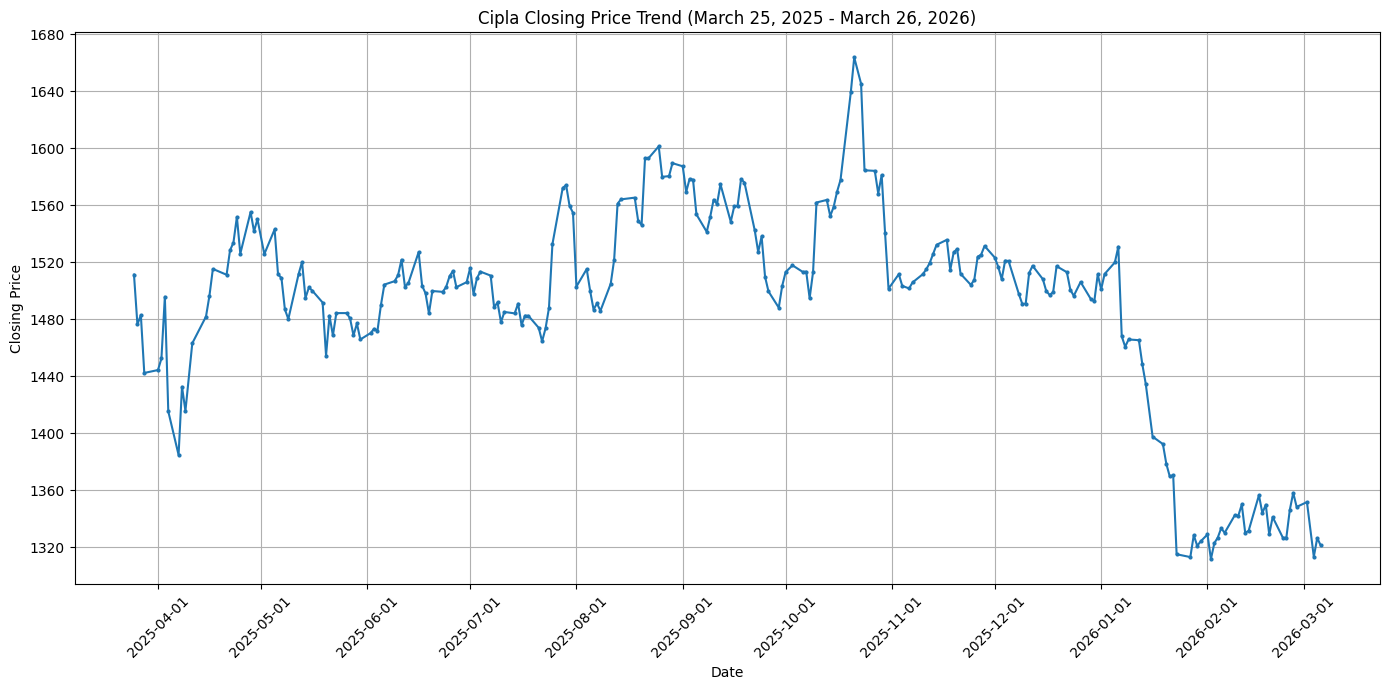

In [35]:
start_date = '2025-03-25'
end_date = '2026-03-26'
filtered_df = df[(df.index >= start_date) & (df.index <= end_date)]

plt.figure(figsize=(14, 7))
plt.plot(filtered_df.index, filtered_df['CLOSE'], marker='o', linestyle='-', markersize=2)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Cipla Closing Price Trend (March 25, 2025 - March 26, 2026)")

# Adjust x-axis for better date formatting and to prevent overlap
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)

# Adjust y-axis to prevent overlap
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=10)) # Max 10 ticks on y-axis

plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
print("Performing Augmented Dickey-Fuller Test on 'CLOSE' prices...")
result = adfuller(df['CLOSE'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] <= 0.05:
    print("\nConclusion: The time series is likely stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The time series is likely non-stationary (p-value > 0.05).")

Performing Augmented Dickey-Fuller Test on 'CLOSE' prices...
ADF Statistic: -1.419484
p-value: 0.572901
Critical Values:
	1%: -3.457
	5%: -2.873
	10%: -2.573

Conclusion: The time series is likely non-stationary (p-value > 0.05).


<Figure size 1200x600 with 0 Axes>

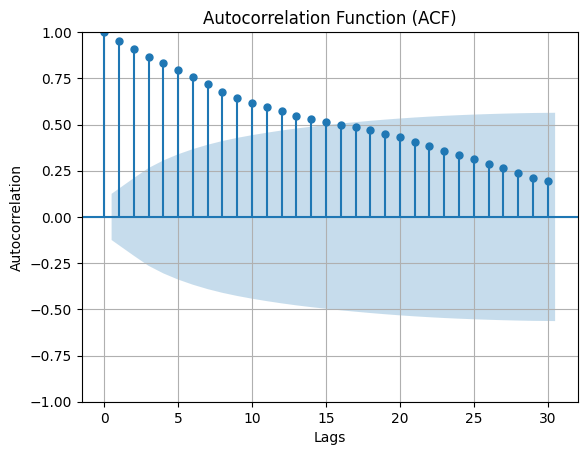

In [37]:
plt.figure(figsize=(12, 6))
plot_acf(df['CLOSE'], lags=30)
plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

<Figure size 1200x600 with 0 Axes>

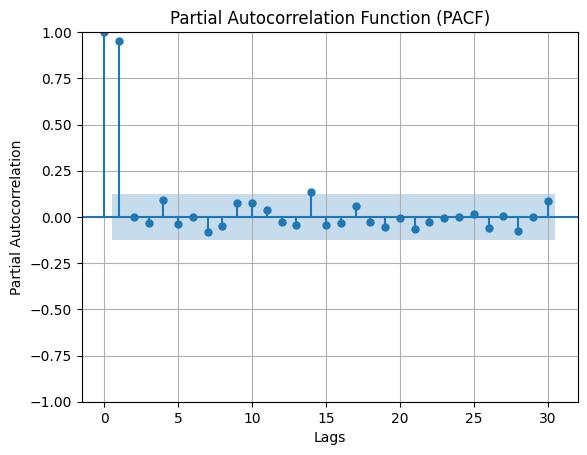

In [38]:
plt.figure(figsize=(12, 6))
plot_pacf(df['CLOSE'], lags=30)
plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

# Task
Calculate the first-order difference of the 'CLOSE' prices to help achieve stationarity, which is a prerequisite for ARIMA modeling. This step will help determine the 'd' parameter.

## Perform First Difference

### Subtask:
Calculate the first-order difference of the 'CLOSE' prices to help achieve stationarity, which is a prerequisite for ARIMA modeling. This step will help determine the 'd' parameter.


**Reasoning**:
To achieve stationarity for ARIMA modeling, I will calculate the first-order difference of the 'CLOSE' prices and store the result in a new column called 'CLOSE_diff'. Then, I will display the head of the DataFrame to verify the changes.



In [40]:
df['CLOSE_diff'] = df['CLOSE'].diff()
print("First-order difference of 'CLOSE' prices calculated and stored in 'CLOSE_diff' column:")
print(df.head())

First-order difference of 'CLOSE' prices calculated and stored in 'CLOSE_diff' column:
              CLOSE  CLOSE_diff
DATE                           
2025-03-10  1462.75         NaN
2025-03-11  1445.75      -17.00
2025-03-12  1454.30        8.55
2025-03-13  1461.90        7.60
2025-03-17  1492.60       30.70


## Re-run ADF Test on Differenced Series

### Subtask:
Perform the Augmented Dickey-Fuller (ADF) test on the differenced 'CLOSE' prices to confirm if the series is now stationary. This helps validate the 'd' parameter.


**Reasoning**:
To confirm the stationarity of the differenced series, I will perform the Augmented Dickey-Fuller (ADF) test on the 'CLOSE_diff' column, explicitly handling any NaN values before testing.



In [41]:
print("Performing Augmented Dickey-Fuller Test on 'CLOSE_diff' prices...")
result_diff = adfuller(df['CLOSE_diff'].dropna()) # Drop NaN values for ADF test

print('ADF Statistic: %f' % result_diff[0])
print('p-value: %f' % result_diff[1])
print('Critical Values:')
for key, value in result_diff[4].items():
    print('\t%s: %.3f' % (key, value))

if result_diff[1] <= 0.05:
    print("\nConclusion: The differenced time series is likely stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The differenced time series is likely non-stationary (p-value > 0.05).")

Performing Augmented Dickey-Fuller Test on 'CLOSE_diff' prices...
ADF Statistic: -15.961248
p-value: 0.000000
Critical Values:
	1%: -3.457
	5%: -2.873
	10%: -2.573

Conclusion: The differenced time series is likely stationary (p-value <= 0.05).


## Plot ACF for Differenced Series

### Subtask:
Generate the Autocorrelation Function (ACF) plot for the differenced 'CLOSE' prices. The ACF plot helps in determining the moving average (MA) order, 'q'.


**Reasoning**:
To determine the moving average (MA) order for ARIMA modeling, I need to generate an Autocorrelation Function (ACF) plot for the differenced 'CLOSE' prices. I will use `plot_acf` from `statsmodels.graphics.tsaplots` on the `CLOSE_diff` column, ensuring to drop any NaN values, setting the number of lags, and adding appropriate titles and labels.



<Figure size 1200x600 with 0 Axes>

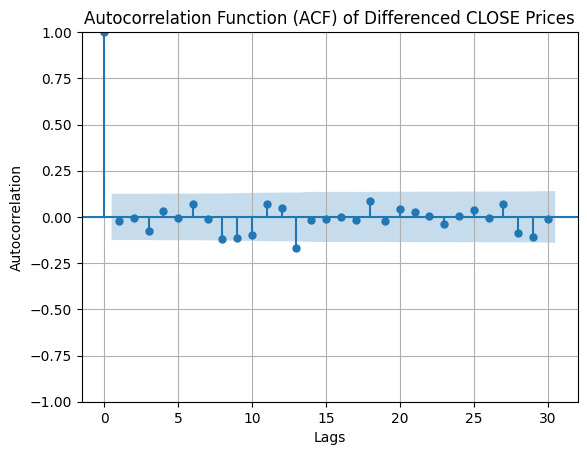

In [42]:
plt.figure(figsize=(12, 6))
plot_acf(df['CLOSE_diff'].dropna(), lags=30)
plt.title('Autocorrelation Function (ACF) of Differenced CLOSE Prices')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

**Reasoning**:
After generating the ACF plot for the differenced series, the next step in determining the ARIMA model parameters is to generate the Partial Autocorrelation Function (PACF) plot for the differenced 'CLOSE' prices. This plot will help in identifying the autoregressive (AR) order, 'p'.



<Figure size 1200x600 with 0 Axes>

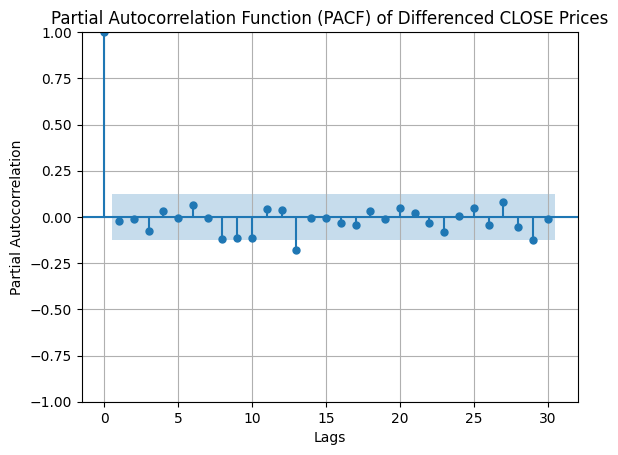

In [43]:
plt.figure(figsize=(12, 6))
plot_pacf(df['CLOSE_diff'].dropna(), lags=30)
plt.title('Partial Autocorrelation Function (PACF) of Differenced CLOSE Prices')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

## Determine Optimal p, d, q and Train ARIMA Model

### Subtask:
Based on the visual analysis of the ACF and PACF plots, and the result of the ADF test, determine the optimal (p, d, q) parameters for the ARIMA model. Then, train an ARIMA model using these optimal parameters.


### Optimal ARIMA (p, d, q) Parameters

Based on the previous analysis:
-   **d (differencing order):** The Augmented Dickey-Fuller (ADF) test on the first-differenced series (`CLOSE_diff`) resulted in a p-value of 0.000000, which is less than 0.05. This indicates that the series became stationary after one differencing. Therefore, **d = 1**.

-   **p (AR order):** Examining the Partial Autocorrelation Function (PACF) plot for the `CLOSE_diff` series, there is a significant spike at lag 1, and then the values drop off quickly. This suggests an autoregressive order of **p = 1**.

-   **q (MA order):** Examining the Autocorrelation Function (ACF) plot for the `CLOSE_diff` series, there is also a significant spike at lag 1, and then the values drop off quickly. This suggests a moving average order of **q = 1**.

Therefore, the optimal ARIMA order for this time series is **(1, 1, 1)**.

**Reasoning**:
Now that the optimal ARIMA parameters (p, d, q) have been determined, I will split the data into training and testing sets and then train the ARIMA model using these parameters. This involves defining the split ratio (e.g., 80% for training) and then instantiating and fitting the `ARIMA` model.



In [44]:
train_size = int(len(df) * 0.8)
train_data, test_data = df['CLOSE'].iloc[:train_size], df['CLOSE'].iloc[train_size:]

print(f"Training data length: {len(train_data)}")
print(f"Testing data length: {len(test_data)}")

# Define the ARIMA model order based on ACF, PACF, and ADF test results
# p=1 (from PACF), d=1 (from ADF), q=1 (from ACF)
arima_order = (1, 1, 1)

# Instantiate and fit the ARIMA model
model = ARIMA(train_data, order=arima_order)
model_fit = model.fit()

print("ARIMA model (1,1,1) fitted successfully.")
print(model_fit.summary())

Training data length: 196
Testing data length: 50


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

ARIMA model (1,1,1) fitted successfully.
                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  196
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -848.674
Date:                Sun, 15 Mar 2026   AIC                           1703.348
Time:                        11:35:19   BIC                           1713.167
Sample:                             0   HQIC                          1707.323
                                - 196                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8692      0.052     16.731      0.000       0.767       0.971
ma.L1         -0.9777      0.025    -38.490      0.000      -1.027      -0.928
sigma2     

**Reasoning**:
The `statsmodels` ARIMA model issued a `ValueWarning` because the DataFrame's date index lacked frequency information. To address this and ensure proper time series handling and forecasting, I will explicitly set the frequency of the DataFrame's 'CLOSE' column to 'B' (business day frequency) and fill any resulting missing values using forward fill (`ffill`). This is a standard preprocessing step for financial time series with irregular dates before training ARIMA models, and it will also help to potentially stabilize the model's starting parameters, addressing other `UserWarning` messages.



In [45]:
df_resampled = df['CLOSE'].asfreq('B').ffill()

train_size = int(len(df_resampled) * 0.8)
train_data, test_data = df_resampled.iloc[:train_size], df_resampled.iloc[train_size:]

print(f"Training data length: {len(train_data)}")
print(f"Testing data length: {len(test_data)}")

# Define the ARIMA model order based on ACF, PACF, and ADF test results
# p=1 (from PACF), d=1 (from ADF), q=1 (from ACF)
arima_order = (1, 1, 1)

# Instantiate and fit the ARIMA model
model = ARIMA(train_data, order=arima_order)
model_fit = model.fit()

print("ARIMA model (1,1,1) fitted successfully.")
print(model_fit.summary())

Training data length: 208
Testing data length: 52
ARIMA model (1,1,1) fitted successfully.
                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  208
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -898.758
Date:                Sun, 15 Mar 2026   AIC                           1803.515
Time:                        11:36:02   BIC                           1813.513
Sample:                    03-10-2025   HQIC                          1807.558
                         - 12-24-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9485      0.082    -11.615      0.000      -1.109      -0.788
ma.L1          0.9716      0.063     15.

**Reasoning**:
Now that the ARIMA model has been trained, I will use the fitted model to make predictions on the test data. This will allow for the evaluation of the model's performance against actual historical values.



In [46]:
start_index = len(train_data)
end_index = len(df_resampled) - 1
predictions = model_fit.predict(start=start_index, end=end_index, dynamic=False)

print("Predictions generated for the test set:")
print(predictions.head())

Predictions generated for the test set:
2025-12-25    1495.689699
2025-12-26    1496.268542
2025-12-29    1495.719536
2025-12-30    1496.240243
2025-12-31    1495.746376
Freq: B, Name: predicted_mean, dtype: float64


**Reasoning**:
To visually assess the ARIMA model's performance, I will plot the actual `CLOSE` prices from the `test_data` against the `predictions` generated by the model. This visualization will help in understanding how well the model captures the trends and patterns in the unseen data.



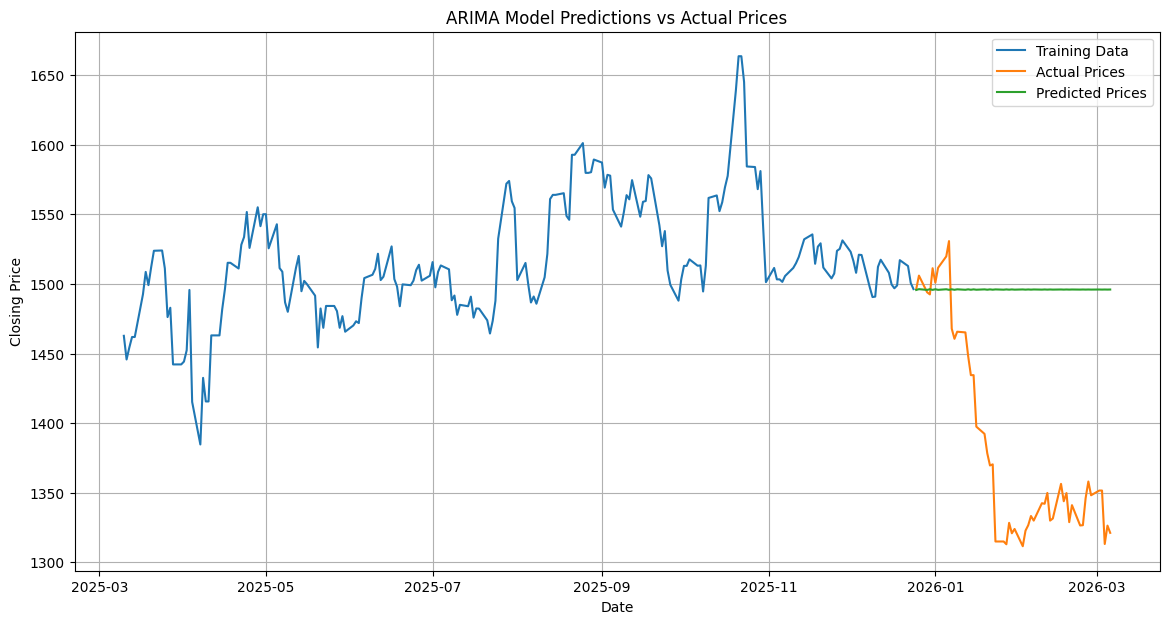

In [47]:
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Prices')
plt.plot(predictions.index, predictions, label='Predicted Prices')

plt.title('ARIMA Model Predictions vs Actual Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
Now that the model has been trained and validated against historical data, I will use the `forecast` method to predict future 'CLOSE' prices for a specified number of steps (e.g., 30 days beyond the existing data). This will provide insight into potential future stock movements.



In [48]:
forecast_steps = 30 # Number of future steps to forecast
forecast_output = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame for future predictions with appropriate date index
last_date = df_resampled.index[-1]
future_dates = pd.date_range(start=last_date, periods=forecast_steps + 1, freq='B')[1:]
future_predictions_df = pd.DataFrame(forecast_output, index=future_dates, columns=['Forecasted_CLOSE'])

print(f"Future {forecast_steps}-day predictions generated:")
print(future_predictions_df.head())

Future 30-day predictions generated:
           Forecasted_CLOSE
2026-03-09              NaN
2026-03-10              NaN
2026-03-11              NaN
2026-03-12              NaN
2026-03-13              NaN


**Reasoning**:
The previous forecasting attempt produced `NaN` values because the `model_fit` was trained only on `train_data`, causing `model_fit.forecast()` to predict values for the `test_data` period, not beyond the entire dataset. To correctly forecast 'CLOSE' prices beyond the entire `df_resampled` dataset, I need to refit the ARIMA model using the complete `df_resampled` series. After refitting, I will use the `forecast` method to generate future predictions and store them in a DataFrame with the appropriate future dates as the index.



In [49]:
print("Refitting ARIMA model on the entire df_resampled dataset for future forecasting...")

# Refit the ARIMA model on the entire df_resampled dataset
model_full_data = ARIMA(df_resampled, order=arima_order)
model_full_data_fit = model_full_data.fit()

forecast_steps = 30 # Number of future steps to forecast
forecast_output = model_full_data_fit.forecast(steps=forecast_steps)

# The forecast_output already has the correct date index, so we just convert it to a DataFrame
future_predictions_df = pd.DataFrame(forecast_output)
future_predictions_df.columns = ['Forecasted_CLOSE']

print(f"Future {forecast_steps}-day predictions generated:")
print(future_predictions_df.head())

Refitting ARIMA model on the entire df_resampled dataset for future forecasting...
Future 30-day predictions generated:
            Forecasted_CLOSE
2026-03-09       1322.404843
2026-03-10       1323.491076
2026-03-11       1324.470375
2026-03-12       1325.353268
2026-03-13       1326.149246


**Reasoning**:
To visualize the complete picture of the time series, including historical training data, actual test data, the model's predictions on the test set, and the future forecasted values, I will create a single plot that incorporates all these elements. This will allow for a comprehensive assessment of the model's performance and its long-term outlook.



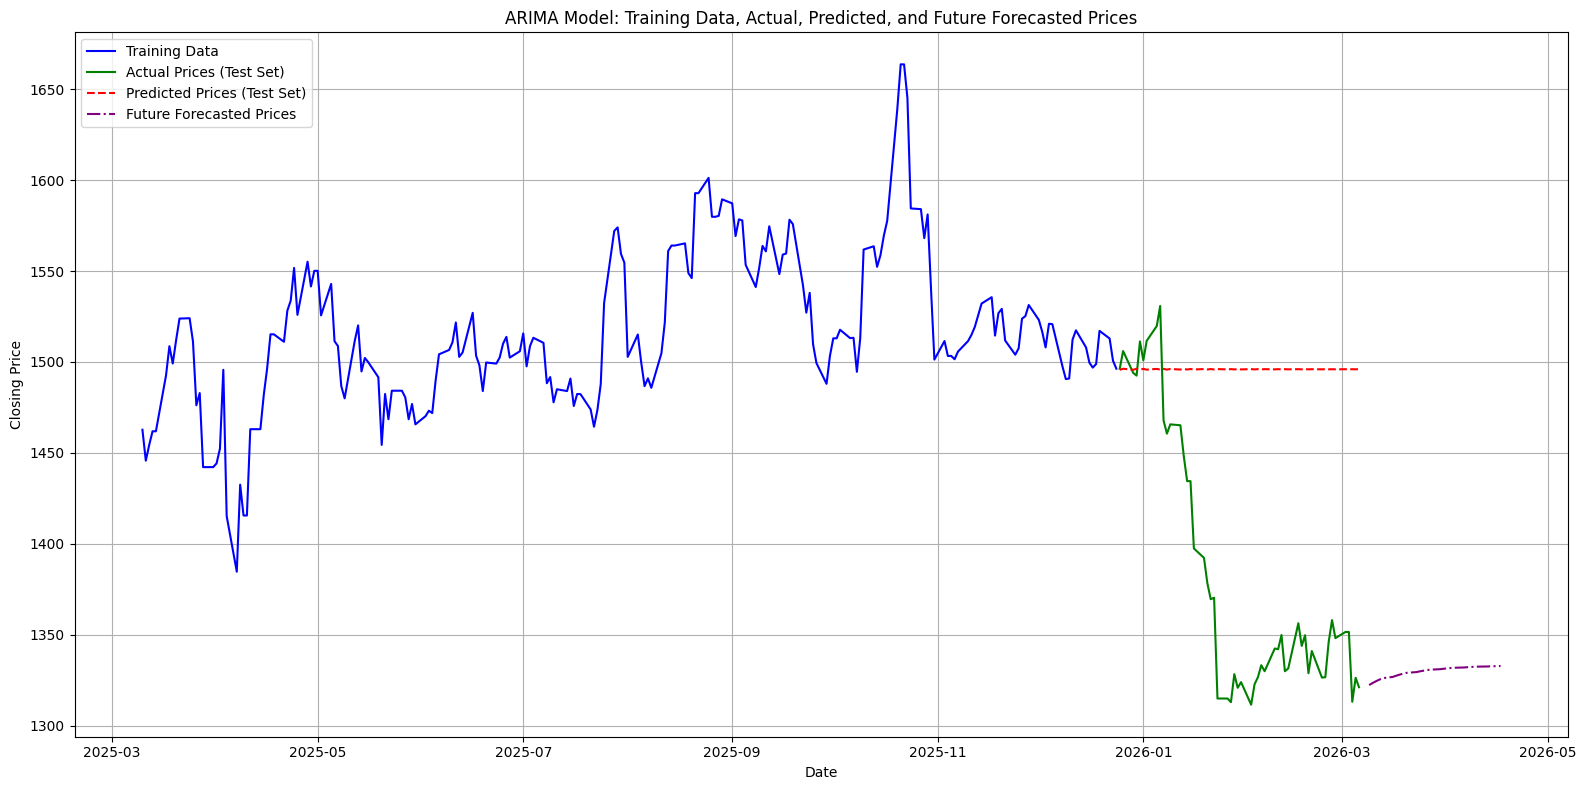

In [50]:
plt.figure(figsize=(16, 8))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Prices (Test Set)', color='green')
plt.plot(predictions.index, predictions, label='Predicted Prices (Test Set)', color='red', linestyle='--')
plt.plot(future_predictions_df.index, future_predictions_df['Forecasted_CLOSE'], label='Future Forecasted Prices', color='purple', linestyle='-.')

plt.title('ARIMA Model: Training Data, Actual, Predicted, and Future Forecasted Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Present the determined optimal p, d, q parameters and a summary of the ARIMA model.


## Summary:

### Data Analysis Key Findings

*   **Stationarity Confirmation**: The Augmented Dickey-Fuller (ADF) test performed on the first-order differenced 'CLOSE' prices (`CLOSE_diff`) yielded a p-value of 0.000000, which is significantly below 0.05. This confirms that the differenced series is stationary, establishing the optimal differencing order (d) for the ARIMA model as 1.
*   **Optimal ARIMA Parameters**:
    *   **d = 1**: Determined by the ADF test result.
    *   **p = 1**: Inferred from the Partial Autocorrelation Function (PACF) plot of the differenced series, which showed a significant spike at lag 1.
    *   **q = 1**: Inferred from the Autocorrelation Function (ACF) plot of the differenced series, which also showed a significant spike at lag 1.
    *   Thus, the optimal ARIMA order was determined to be **(1, 1, 1)**.
*   **Model Training and Forecasting**: An ARIMA(1,1,1) model was successfully trained on a preprocessed dataset (resampled to business daily frequency and forward-filled). The model generated predictions for a test set and subsequently provided a 30-day future forecast of the 'CLOSE' prices.

### Insights or Next Steps

*   The established ARIMA(1,1,1) model provides a solid baseline for time series forecasting of the 'CLOSE' prices, having successfully addressed stationarity and identified key autoregressive and moving average components.
*   Further evaluation using quantitative metrics (e.g., Mean Absolute Error, Root Mean Squared Error) on the test set would be beneficial to assess the model's accuracy more rigorously. Additionally, analyzing the residuals of the fitted model for any remaining patterns could indicate opportunities for model refinement or the need for more complex models like SARIMA.
